In [7]:
### Start this clinical Use this code block first


import requests
import time

# Define the genes and their categories.
gene_categories1 = {
    "Emerging Breast Cancer Target": ['CASP8', 'FOXO3a'],
    "Lacks Breast Cancer Evidence": ['CDKN1A', 'BAX', 'NRAS', 'VHL', 'SRC', 'NF2', 'WT1', 'NTRK1']
}


# The base URL for the modernized ClinicalTrials.gov API (v2.0).
API_BASE_URL = "https://clinicaltrials.gov/api/v2/studies"
HEADERS = {'Accept': 'application/json'}

def search_studies_for_gene(gene_name):
    """
    Searches the ClinicalTrials.gov API for studies related to a given gene
    and the condition "Breast Cancer".
    
    Args:
        gene_name (str): The gene to search for.
        
    Returns:
        list: A list of dictionaries, where each dictionary represents a study.
    """
    # Construct a specific query for 'Breast Cancer' and the gene.
    search_query = f'"Breast Cancer" AND {gene_name}'
    
    # The API request parameters.
    params = {
        "query.term": search_query,
        "pageSize": 100 # Retrieve up to 100 studies per call.
    }
    
    studies = []
    
    try:
        print(f"Searching for studies with query: '{search_query}'...")
        response = requests.get(API_BASE_URL, headers=HEADERS, params=params)
        response.raise_for_status() # Raise an error for bad status codes
        
        data = response.json()
        
        # The studies are in a list under the 'studies' key.
        if 'studies' in data:
            studies = data['studies']
            print(f"-> API search found {len(studies)} total studies for '{search_query}'.")
        else:
            print(f"-> No studies found for '{search_query}'.")

    except requests.exceptions.RequestException as e:
        print(f"An API error occurred for query '{search_query}': {e}")
        
    return studies

def extract_and_display_studies(studies, gene_name):
    """
    Extracts key details and displays them for the found studies.
    
    Args:
        studies (list): The list of study dictionaries from the API.
        gene_name (str): The gene name for context.
    """
    found_count = len(studies)
    if found_count > 0:
        print(f"\nFound {found_count} studies for gene '{gene_name}' in Breast Cancer:")
        for study in studies:
            # Extract key details from the nested JSON structure.
            identification_module = study.get("protocolSection", {}).get("identificationModule", {})
            nct_id = identification_module.get("nctId")
            study_title = identification_module.get("briefTitle")
            conditions = study.get("protocolSection", {}).get("conditionsModule", {}).get("conditions", [])

            print(f"   - NCT ID: {nct_id}")
            print(f"     Title: {study_title}")
            print(f"     Conditions: {', '.join(conditions)}")
            print("-" * 50)
    else:
        print(f"\nNo studies found for gene '{gene_name}' in Breast Cancer.")

# Main execution loop to analyze all genes.
print("Starting search for Breast Cancer studies related to each gene...")
final_summary1 = {}

for category, genes in gene_categories1.items():
    final_summary1[category] = {}
    print(f"\n=======================================================")
    print(f"Searching genes in category: '{category}'")
    print(f"=======================================================")
    
    for gene in genes:
        studies_found = search_studies_for_gene(gene)
        extract_and_display_studies(studies_found, gene)
        final_summary1[category][gene] = len(studies_found)
        
        # Add a delay to be respectful of the API's rate limits.
        time.sleep(1)

print("\n\n" + "="*50)
print("FINAL SUMMARY OF ALL SEARCHES")
print("="*50)
for category, genes_data in final_summary1.items():
    print(f"\nCategory: {category}")
    for gene, count in genes_data.items():
        print(f"  - Gene '{gene}': {count} studies found.")
print("="*50)

Starting search for Breast Cancer studies related to each gene...

Searching genes in category: 'Emerging Breast Cancer Target'
Searching for studies with query: '"Breast Cancer" AND CASP8'...
-> API search found 1 total studies for '"Breast Cancer" AND CASP8'.

Found 1 studies for gene 'CASP8' in Breast Cancer:
   - NCT ID: NCT01440413
     Title: Study of the Response to a Neoadjuvant Chemotherapy Based on the Antitumor Immune Response in Localized Breast Cancer
     Conditions: Breast Cancer
--------------------------------------------------
Searching for studies with query: '"Breast Cancer" AND FOXO3a'...
-> API search found 4 total studies for '"Breast Cancer" AND FOXO3a'.

Found 4 studies for gene 'FOXO3a' in Breast Cancer:
   - NCT ID: NCT02326844
     Title: BMN 673 (Talazoparib), an Oral PARP Inhibitor, in People With Deleterious BRCA1/2 Mutation-Associated Ovarian Cancer Who Have Had Prior PARP Inhibitor Treatment
     Conditions: Ovarian Cancer
------------------------------

In [8]:
import requests
import json
import time

# Define the two new sets of genes and their categories.
gene_categories2 = {
    "FDA-approved Breast Cancer Therapy": [
        'CDK4', 'ERBB2', 'CCND1', 'CDKN2A', 'FOXO3a', 'KRAS', 'FGFR1',
        'MDM2', 'NF1', 'AKT1', 'BRCA1', 'HRAS', 'TP53', 'CDK6', 'PTEN',
        'MYC', 'BRCA2', 'PIK3CA', 'RB1', 'BCL2', 'MET', 'EGFR', 'NTRK2',
        'TSC2', 'STK11', 'FGFR2', 'ATR', 'NOTCH1', 'SMAD4', 'CHEK2', 'ATM'
    ],
    "FDA-approved Other Indication": [
        'CCND1', 'CDKN2A', 'FOXO3a', 'MDM2', 'NF1', 'HRAS', 'PTEN', 'RB1',
        'BCL2', 'MET', 'NTRK2', 'TSC2', 'STK11', 'ATR', 'NOTCH1', 'SMAD4',
        'CHEK2', 'ATM'
    ]
}

# The base URL for the modernized ClinicalTrials.gov API (v2.0).
API_BASE_URL = "https://clinicaltrials.gov/api/v2/studies"
HEADERS = {'Accept': 'application/json'}

def search_studies_for_gene(gene_name, condition="Breast Cancer"):
    """
    Searches the ClinicalTrials.gov API for studies related to a given gene
    and a specified condition.
    
    Args:
        gene_name (str): The gene to search for.
        condition (str): The condition to search for. Defaults to "Breast Cancer".
        
    Returns:
        list: A list of dictionaries, where each dictionary represents a study.
    """
    # Construct a specific query for the condition and the gene.
    # The API's 'query.term' parameter is used for a broad text search.
    search_query = f'"{condition}" AND {gene_name}'
    
    params = {
        "query.term": search_query,
        "pageSize": 100  # Retrieve up to 100 studies per call for a broad search.
    }
    
    studies = []
    
    try:
        print(f"Searching for studies with query: '{search_query}'...")
        response = requests.get(API_BASE_URL, headers=HEADERS, params=params)
        response.raise_for_status() # Raise an error for bad status codes
        
        data = response.json()
        
        if 'studies' in data:
            studies = data['studies']
            print(f"-> API search found {len(studies)} total studies for '{search_query}'.")
        else:
            print(f"-> No studies found for '{search_query}'.")

    except requests.exceptions.RequestException as e:
        print(f"An API error occurred for query '{search_query}': {e}")
        
    return studies

def extract_and_display_studies(studies, gene_name):
    """
    Extracts key details and displays them for the found studies.
    
    Args:
        studies (list): The list of study dictionaries from the API.
        gene_name (str): The gene name for context.
    """
    found_count = len(studies)
    if found_count > 0:
        print(f"\nFound {found_count} studies for gene '{gene_name}' in Breast Cancer:")
        for study in studies:
            # Extract key details from the nested JSON structure.
            identification_module = study.get("protocolSection", {}).get("identificationModule", {})
            nct_id = identification_module.get("nctId")
            study_title = identification_module.get("briefTitle")
            
            # The conditions are now in a new nested path in the API v2.0
            conditions_module = study.get("protocolSection", {}).get("conditionsModule", {})
            conditions = conditions_module.get("conditions", [])

            print(f"   - NCT ID: {nct_id}")
            print(f"     Title: {study_title}")
            print(f"     Conditions: {', '.join(conditions)}")
            print("-" * 50)
    else:
        print(f"\nNo studies found for gene '{gene_name}' in Breast Cancer.")

# Main execution loop to analyze all genes.
print("Starting search for Breast Cancer studies related to all genes...")
final_summary2 = {}

for category, genes in gene_categories2.items():
    final_summary2[category] = {}
    print(f"\n=======================================================")
    print(f"Searching genes in category: '{category}'")
    print(f"=======================================================")
    
    for gene in genes:
        studies_found = search_studies_for_gene(gene)
        extract_and_display_studies(studies_found, gene)
        final_summary2[category][gene] = len(studies_found)
        
        # Add a delay to be respectful of the API's rate limits.
        time.sleep(1)

print("\n\n" + "="*50)
print("FINAL SUMMARY OF ALL SEARCHES")
print("="*50)
for category, genes_data in final_summary2.items():
    print(f"\nCategory: {category}")
    for gene, count in genes_data.items():
        print(f"  - Gene '{gene}': {count} studies found.")
print("="*50)

Starting search for Breast Cancer studies related to all genes...

Searching genes in category: 'FDA-approved Breast Cancer Therapy'
Searching for studies with query: '"Breast Cancer" AND CDK4'...
-> API search found 100 total studies for '"Breast Cancer" AND CDK4'.

Found 100 studies for gene 'CDK4' in Breast Cancer:
   - NCT ID: NCT05305924
     Title: Fulvestrant+Abemaciclib With Run-In of Fulvestrant in Er-Positive, Her2-Negative Metastatic Breast Cancer
     Conditions: ER-Positive Breast Cancer, HER2-negative Breast Cancer
--------------------------------------------------
   - NCT ID: NCT05809024
     Title: Select the Appropriate Population for Adding CDK4/6i to Neoadjuvant Endocrine Therapy
     Conditions: Locally Advanced Breast Cancer, Hormone Receptor Positive，HER2-negative Breast Cancer
--------------------------------------------------
   - NCT ID: NCT02978716
     Title: Trilaciclib (G1T28), a CDK 4/6 Inhibitor, in Combination With Gemcitabine and Carboplatin in Metasta

In [10]:
## Combine both final summaries into a single DataFrame

def combine_summaries(*summaries):
    """
    Combine multiple final_summary dicts dynamically into one DataFrame,
    assign categories with priority based on total studies per category,
    and keep unique genes assigned to highest priority category.
    """
    # Step 1: Convert each dict to a DataFrame and concat
    dfs = []
    for summary in summaries:
        rows = []
        for category, genes_dict in summary.items():
            for gene, count in genes_dict.items():
                rows.append({"gene": gene, "studies": count, "category": category})
        dfs.append(pd.DataFrame(rows))
    combined_df = pd.concat(dfs, ignore_index=True)

    # Step 2: Dynamically determine category priority by total studies (descending)
    cat_studies = combined_df.groupby('category')['studies'].sum().sort_values(ascending=False)
    category_priority = list(cat_studies.index)
    priority_map = {cat: i for i, cat in enumerate(category_priority)}

    # Step 3: Assign priority index for each row based on category
    combined_df['priority'] = combined_df['category'].map(priority_map)

    # Step 4: Sort by gene and priority (keep highest priority category per gene)
    combined_df = combined_df.sort_values(by=['gene', 'priority', 'studies'], ascending=[True, True, False])

    # Step 5: Drop duplicates keeping the first occurrence per gene (highest priority)
    unique_df = combined_df.drop_duplicates(subset='gene', keep='first').reset_index(drop=True)

    # Step 6: Drop priority column
    unique_df = unique_df.drop(columns=['priority'])

    return unique_df, category_priority

# Usage example with your final_summary dicts:
df_final, cat_priority = combine_summaries(final_summary1, final_summary2)

print("Category priority order detected:", cat_priority)
print(df_final.sample(20))

Category priority order detected: ['FDA-approved Breast Cancer Therapy', 'FDA-approved Other Indication', 'Lacks Breast Cancer Evidence', 'Emerging Breast Cancer Target']
      gene  studies                            category
37    TSC2        1  FDA-approved Breast Cancer Therapy
19    HRAS        4  FDA-approved Breast Cancer Therapy
1      ATM       43  FDA-approved Breast Cancer Therapy
13   CHEK2       17  FDA-approved Breast Cancer Therapy
38     VHL        1        Lacks Breast Cancer Evidence
5    BRCA1      100  FDA-approved Breast Cancer Therapy
21    MDM2        9  FDA-approved Breast Cancer Therapy
8    CCND1       34  FDA-approved Breast Cancer Therapy
23     MYC       15  FDA-approved Breast Cancer Therapy
24     NF1       11  FDA-approved Breast Cancer Therapy
31    PTEN      100  FDA-approved Breast Cancer Therapy
4     BCL2       24  FDA-approved Breast Cancer Therapy
12  CDKN2A       27  FDA-approved Breast Cancer Therapy
16   FGFR1       21  FDA-approved Breast Canc

In [11]:
df_final.shape

(40, 3)

In [12]:
import pandas as pd

# Assuming you have df_final like this (with columns: gene, studies, category)

# Define category priority order (highest priority first)
category_priority = [
    "FDA-approved Breast Cancer Therapy",
    "FDA-approved Other Indication",
    "Emerging Breast Cancer Target",
    "Lacks Breast Cancer Evidence"
]

# Create a priority mapping for categories
priority_map = {cat: i for i, cat in enumerate(category_priority)}

# Map priority to each row
df_final['priority'] = df_final['category'].map(priority_map)

# Sort by gene, then by priority (lower priority number = higher priority), then by studies descending if needed
df_final = df_final.sort_values(by=['gene', 'priority', 'studies'], ascending=[True, True, False])

# Drop duplicates, keeping the first occurrence per gene (which has highest priority)
df_unique = df_final.drop_duplicates(subset='gene', keep='first').reset_index(drop=True)

# Drop helper priority column
df_unique = df_unique.drop(columns=['priority'])

# Confirm uniqueness
duplicates = df_unique['gene'][df_unique['gene'].duplicated()]
assert duplicates.empty, f"Duplicated genes found after filtering: {duplicates.tolist()}"

print(df_unique)

      gene  studies                            category
0     AKT1       40  FDA-approved Breast Cancer Therapy
1      ATM       43  FDA-approved Breast Cancer Therapy
2      ATR       19  FDA-approved Breast Cancer Therapy
3      BAX        9        Lacks Breast Cancer Evidence
4     BCL2       24  FDA-approved Breast Cancer Therapy
5    BRCA1      100  FDA-approved Breast Cancer Therapy
6    BRCA2      100  FDA-approved Breast Cancer Therapy
7    CASP8        1       Emerging Breast Cancer Target
8    CCND1       34  FDA-approved Breast Cancer Therapy
9     CDK4      100  FDA-approved Breast Cancer Therapy
10    CDK6       35  FDA-approved Breast Cancer Therapy
11  CDKN1A        2        Lacks Breast Cancer Evidence
12  CDKN2A       27  FDA-approved Breast Cancer Therapy
13   CHEK2       17  FDA-approved Breast Cancer Therapy
14    EGFR      100  FDA-approved Breast Cancer Therapy
15   ERBB2      100  FDA-approved Breast Cancer Therapy
16   FGFR1       21  FDA-approved Breast Cancer 

In [13]:
print(df_unique.groupby('category').size())

category
Emerging Breast Cancer Target          1
FDA-approved Breast Cancer Therapy    31
Lacks Breast Cancer Evidence           8
dtype: int64


In [14]:
## Use this code
import pandas as pd

# Assume df_summary with 'gene' and 'studies' columns, e.g.:
# df_summary = pd.DataFrame({'gene': [...], 'studies': [...]})

# Define thresholds for categories dynamically based on number of studies
def categorize_gene(num_studies):
    if num_studies >= 50:
        return 'High-Confidence Targets'
    elif num_studies >= 20:
        return 'Therapeutic Expansion Targets'
    elif num_studies >= 5:
        return 'Underexplored Targets'
    else:
        return 'Emerging Clinical Targets'

# Apply categorization dynamically
df_unique['category'] = df_unique['studies'].apply(categorize_gene)

# Now, if you want to add drug info dynamically, merge with that DataFrame here

# Example printout to verify
print(df_unique.head(10))

# Optional: Sort categories for plotting
category_order = [
    'High-Confidence Targets',
    'Therapeutic Expansion Targets',
    'Underexplored Targets',
    'Emerging Clinical Targets'
]

df_unique['category'] = pd.Categorical(df_unique['category'], categories=category_order, ordered=True)
df_summary = df_unique.sort_values(by=['category', 'studies'], ascending=[True, False])
df_summary.sample(10) # Display a sample of the DataFrame
# Then you can plot similarly as before

    gene  studies                       category
0   AKT1       40  Therapeutic Expansion Targets
1    ATM       43  Therapeutic Expansion Targets
2    ATR       19          Underexplored Targets
3    BAX        9          Underexplored Targets
4   BCL2       24  Therapeutic Expansion Targets
5  BRCA1      100        High-Confidence Targets
6  BRCA2      100        High-Confidence Targets
7  CASP8        1      Emerging Clinical Targets
8  CCND1       34  Therapeutic Expansion Targets
9   CDK4      100        High-Confidence Targets


,gene,studies,category
8,CCND1,34,Therapeutic Expansion Targets
28,NTRK1,12,Underexplored Targets
2,ATR,19,Underexplored Targets
19,HRAS,4,Emerging Clinical Targets
4,BCL2,24,Therapeutic Expansion Targets
37,TSC2,1,Emerging Clinical Targets
29,NTRK2,4,Emerging Clinical Targets
12,CDKN2A,27,Therapeutic Expansion Targets
6,BRCA2,100,High-Confidence Targets
30,PIK3CA,100,High-Confidence Targets


In [15]:
#3 use this code block 
import requests
import time
import pandas as pd

# Use genes from df_unique to avoid mismatch
genes_to_query = df_unique['gene'].tolist()

BASE_URL = "https://api.platform.opentargets.org/api/v4/graphql"

def get_ensembl_id(gene_symbol):
    search_query = """
    query searchTarget($queryString: String!) {
        search(queryString: $queryString, entityNames: ["target"]) {
            hits {
                id
                entity
                object {
                    ... on Target {
                        approvedSymbol
                    }
                }
            }
        }
    }
    """
    variables = {"queryString": gene_symbol}
    payload = {'query': search_query, 'variables': variables}
    try:
        response = requests.post(BASE_URL, json=payload)
        response.raise_for_status()
        data = response.json()
        hits = data['data']['search']['hits']
        for hit in hits:
            if hit['entity'] == 'target' and hit['object']['approvedSymbol'] == gene_symbol:
                return hit['id']
    except Exception as e:
        print(f"Error finding Ensembl ID for {gene_symbol}: {e}")
    return None

def query_open_targets(ensembl_id):
    query = """
    query getKnownDrugs($ensemblId: String!) {
      target(ensemblId: $ensemblId) {
        id
        knownDrugs {
          rows {
            drug {
              id
              name
            }
            phase
            status
          }
        }
      }
    }
    """
    variables = {"ensemblId": ensembl_id}
    payload = {'query': query, 'variables': variables}
    try:
        response = requests.post(BASE_URL, json=payload)
        response.raise_for_status()
    except requests.exceptions.HTTPError as e:
        print(f"HTTP Error querying drugs for {ensembl_id}: {e}")
        return 'No Specific Drug'
    data = response.json()
    try:
        if data['data']['target'] is not None:
            drugs_info = data['data']['target']['knownDrugs']['rows']
            approved_drugs = [d['drug']['name'] for d in drugs_info if d['phase'] == 4]
            return ', '.join(set(approved_drugs)) if approved_drugs else 'No Specific Drug'
        else:
            return 'No Specific Drug'
    except (TypeError, KeyError):
        return 'No Specific Drug'

# Map genes to Ensembl IDs
gene_ensembl_map = {}
for gene in genes_to_query:
    print(f"Finding Ensembl ID for {gene} ...")
    ensembl_id = get_ensembl_id(gene)
    gene_ensembl_map[gene] = ensembl_id if ensembl_id else None
    time.sleep(0.2)

# Query drugs for Ensembl IDs
gene_drug_map = {}
for gene, ensembl_id in gene_ensembl_map.items():
    if ensembl_id:
        print(f"Querying drugs for {gene} ({ensembl_id}) ...")
        gene_drug_map[gene] = query_open_targets(ensembl_id)
    else:
        gene_drug_map[gene] = 'No Specific Drug'
    time.sleep(0.2)

# Create DataFrame of drug mapping
df_mapping = pd.DataFrame({
    'gene': list(gene_drug_map.keys()),
    'FDA_Approved_Drug': list(gene_drug_map.values())
})

# Merge with df_unique on 'gene'
df_unique = df_unique.merge(df_mapping, on='gene', how='left')

print(df_unique.head(50))
print(df_mapping.head(50))

Finding Ensembl ID for AKT1 ...
Finding Ensembl ID for ATM ...
Finding Ensembl ID for ATR ...
Finding Ensembl ID for BAX ...
Finding Ensembl ID for BCL2 ...
Finding Ensembl ID for BRCA1 ...
Finding Ensembl ID for BRCA2 ...
Finding Ensembl ID for CASP8 ...
Finding Ensembl ID for CCND1 ...
Finding Ensembl ID for CDK4 ...
Finding Ensembl ID for CDK6 ...
Finding Ensembl ID for CDKN1A ...
Finding Ensembl ID for CDKN2A ...
Finding Ensembl ID for CHEK2 ...
Finding Ensembl ID for EGFR ...
Finding Ensembl ID for ERBB2 ...
Finding Ensembl ID for FGFR1 ...
Finding Ensembl ID for FGFR2 ...
Finding Ensembl ID for FOXO3a ...
Finding Ensembl ID for HRAS ...
Finding Ensembl ID for KRAS ...
Finding Ensembl ID for MDM2 ...
Finding Ensembl ID for MET ...
Finding Ensembl ID for MYC ...
Finding Ensembl ID for NF1 ...
Finding Ensembl ID for NF2 ...
Finding Ensembl ID for NOTCH1 ...
Finding Ensembl ID for NRAS ...
Finding Ensembl ID for NTRK1 ...
Finding Ensembl ID for NTRK2 ...
Finding Ensembl ID for PIK3CA

In [16]:
# Drop any existing FDA_Approved_Drug columns (_x, _y) to avoid duplicate columns after merge
cols_to_drop = [col for col in df_unique.columns if 'FDA_Approved_Drug' in col]
df_unique = df_unique.drop(columns=cols_to_drop, errors='ignore')

# Merge df_unique with drug mapping DataFrame on 'gene'
df_unique = df_unique.merge(df_mapping, on='gene', how='left')

# If you suspect duplicate drug columns from previous merges, combine them safely (optional)
if 'FDA_Approved_Drug_x' in df_unique.columns and 'FDA_Approved_Drug_y' in df_unique.columns:
    df_unique['FDA_Approved_Drug'] = df_unique['FDA_Approved_Drug_x'].combine_first(df_unique['FDA_Approved_Drug_y'])
    df_unique = df_unique.drop(columns=['FDA_Approved_Drug_x', 'FDA_Approved_Drug_y'])

# Display the relevant columns to verify
print(df_unique[['gene', 'studies', 'category', 'FDA_Approved_Drug']].head(50))

      gene  studies                       category  \
0     AKT1       40  Therapeutic Expansion Targets   
1      ATM       43  Therapeutic Expansion Targets   
2      ATR       19          Underexplored Targets   
3      BAX        9          Underexplored Targets   
4     BCL2       24  Therapeutic Expansion Targets   
5    BRCA1      100        High-Confidence Targets   
6    BRCA2      100        High-Confidence Targets   
7    CASP8        1      Emerging Clinical Targets   
8    CCND1       34  Therapeutic Expansion Targets   
9     CDK4      100        High-Confidence Targets   
10    CDK6       35  Therapeutic Expansion Targets   
11  CDKN1A        2      Emerging Clinical Targets   
12  CDKN2A       27  Therapeutic Expansion Targets   
13   CHEK2       17          Underexplored Targets   
14    EGFR      100        High-Confidence Targets   
15   ERBB2      100        High-Confidence Targets   
16   FGFR1       21  Therapeutic Expansion Targets   
17   FGFR2        7         

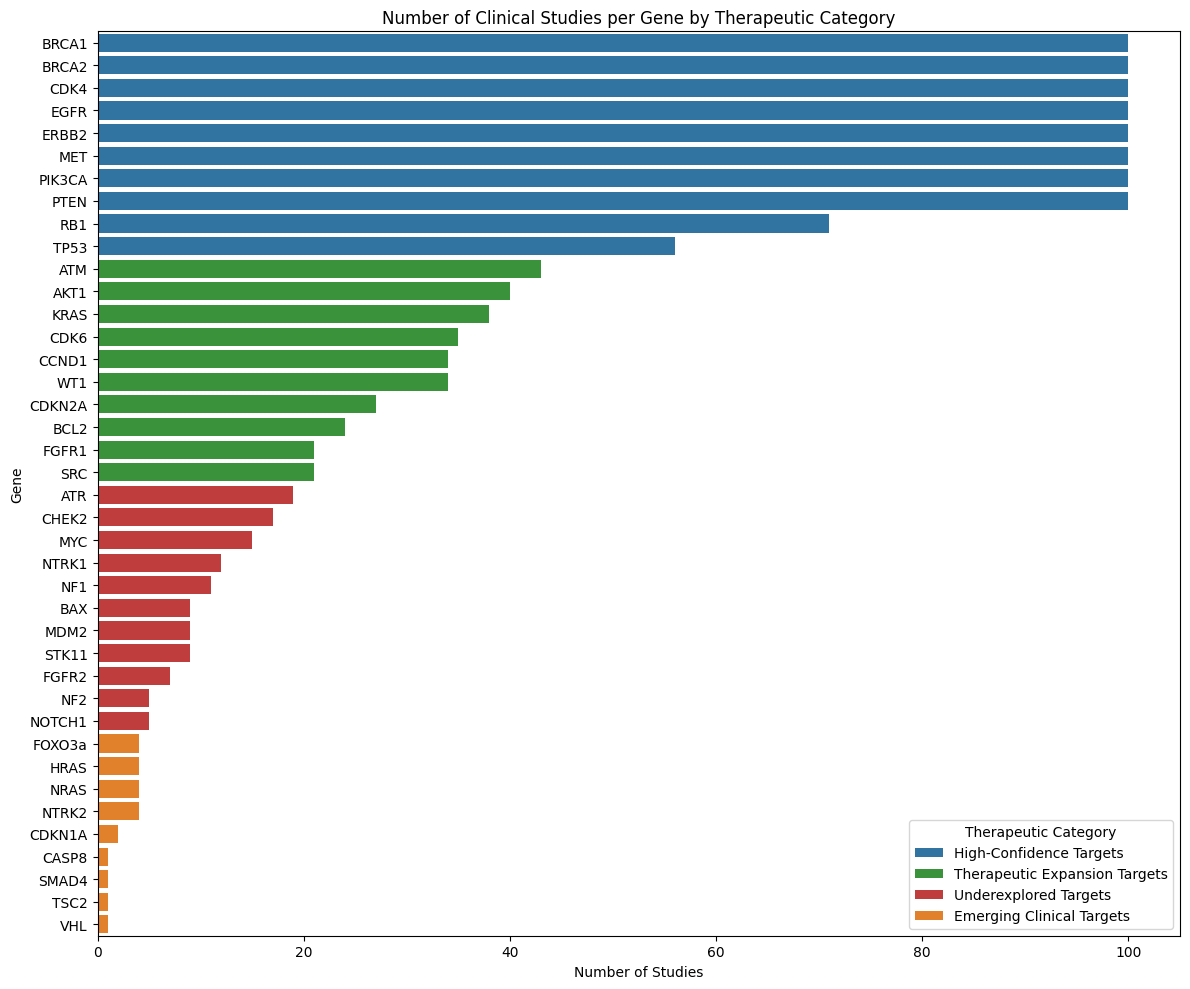

In [18]:
# Plot: Number of Studies per Gene by Category with drug indication colors
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
plt.figure(figsize=(12, 10))
sns.barplot(
    data=df_unique.sort_values(['category', 'studies'], ascending=[True, False]),
    y='gene', x='studies', hue='category', dodge=False,
    palette=['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e']  # Color scheme as needed
)
plt.title("Number of Clinical Studies per Gene by Therapeutic Category")
plt.xlabel("Number of Studies")
plt.ylabel("Gene")
plt.legend(title="Therapeutic Category")
plt.tight_layout()
plt.show()

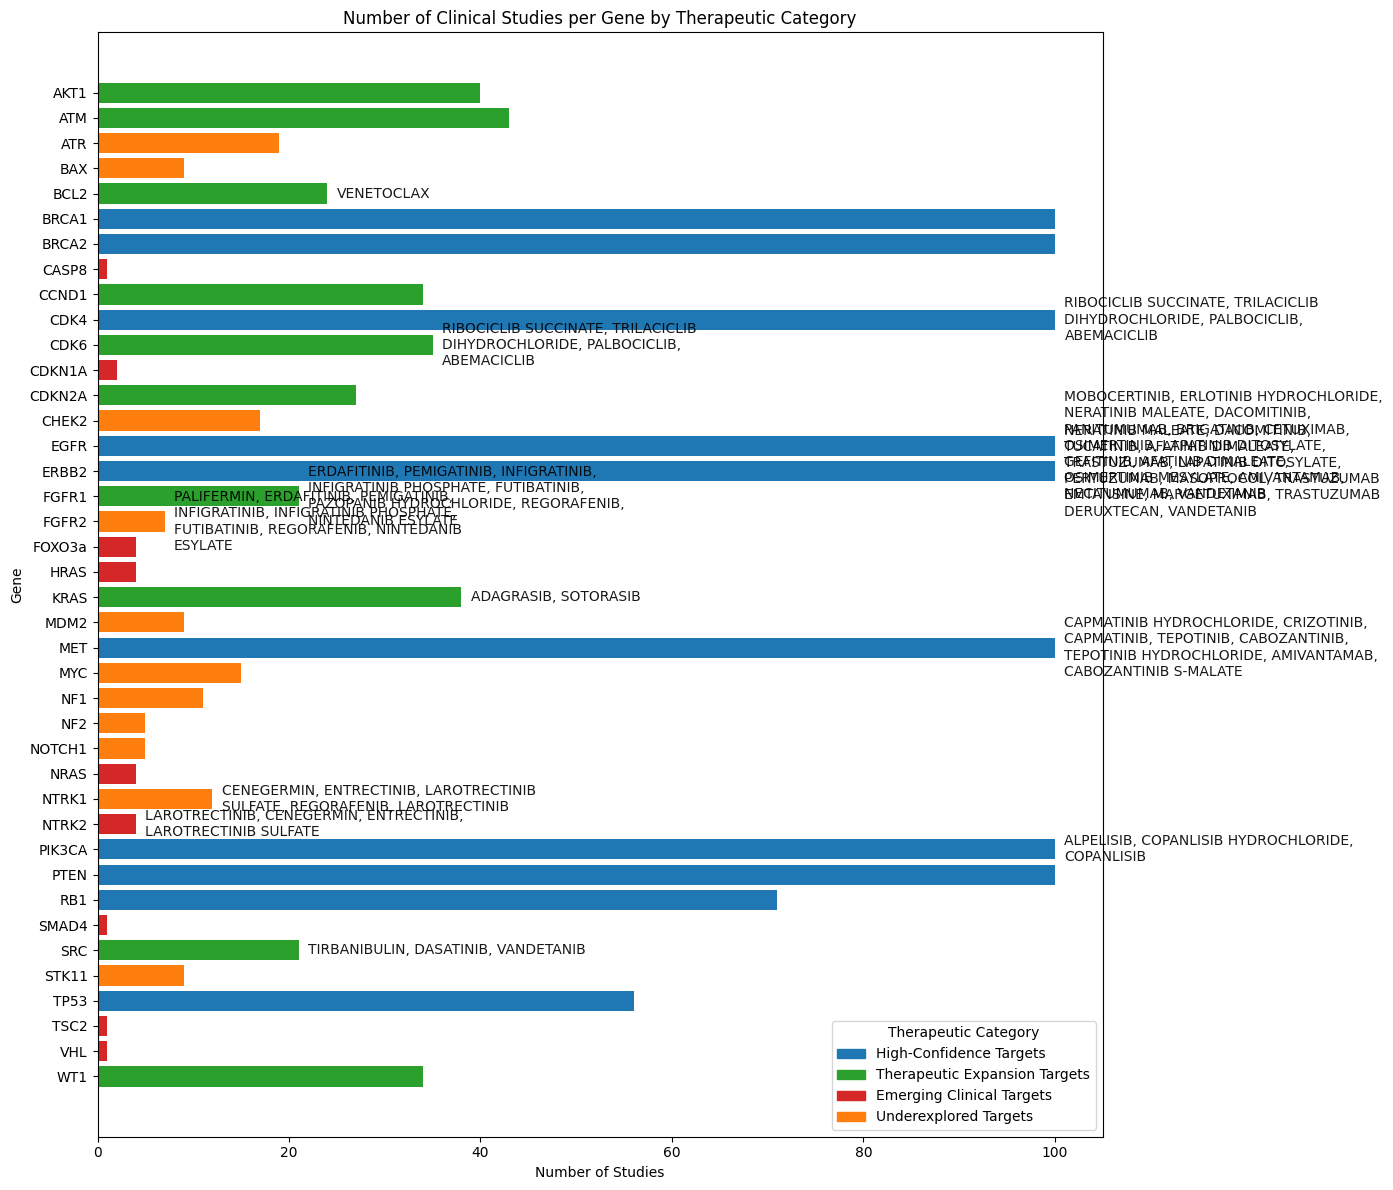

In [21]:
color_map = {
    'High-Confidence Targets': '#1f77b4',       # blue
    'Therapeutic Expansion Targets': '#2ca02c', # green
    'Emerging Clinical Targets': '#d62728',     # red
    'Underexplored Targets': '#ff7f0e'          # orange
}
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textwrap

color_map = {
    'High-Confidence Targets': '#1f77b4',
    'Therapeutic Expansion Targets': '#2ca02c',
    'Emerging Clinical Targets': '#d62728',
    'Underexplored Targets': '#ff7f0e'
}

plt.figure(figsize=(14, 12))

bars = plt.barh(df_unique['gene'], df_unique['studies'], color=df_unique['category'].map(color_map))
plt.xlabel("Number of Studies")
plt.ylabel("Gene")
plt.title("Number of Clinical Studies per Gene by Therapeutic Category")

for bar, drug_names in zip(bars, df_unique['FDA_Approved_Drug']):
    width = bar.get_width()
    if drug_names and drug_names != 'No Specific Drug':
        wrapped_text = "\n".join(textwrap.wrap(drug_names, width=40))
        plt.text(width + 1, bar.get_y() + bar.get_height() / 2, 
                 wrapped_text, va='center', ha='left', fontsize=10, alpha=0.9)

handles = [mpatches.Patch(color=color_map[cat], label=cat) for cat in color_map]
plt.legend(handles=handles, title='Therapeutic Category', loc='lower right')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
